In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
# Configuración de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Configuración de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# URL del dataset oficial
data_url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"

# Carga de datos directa y sin errores de espacio
df = pd.read_csv(data_url, sep=';') 

print("¡Datos cargados con éxito!")
print(f"Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas.\n")


¡Datos cargados con éxito!
Dimensiones iniciales: 41188 filas y 21 columnas.



In [41]:
# Ver las primeras filas
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


2. Análisis Exploratorio de Datos (EDA) Completo y Limpieza

2.1 Limpieza Inicial (Duplicados y Nulos)

In [5]:
# Comprobación de valores nulos
print("--- Conteo de Valores Nulos ---")
print(df.isnull().sum())

--- Conteo de Valores Nulos ---
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [6]:
# Eliminación de registros duplicados
duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados detectados: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"Dimensiones después de eliminar duplicados: {df.shape}")


Registros duplicados detectados: 12
Dimensiones después de eliminar duplicados: (41176, 21)


 2.2 Análisis Univariante: Variable Objetivo (Target)

C:\Users\PC\AppData\Local\Temp\ipykernel_18484\1101414858.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='Set2')


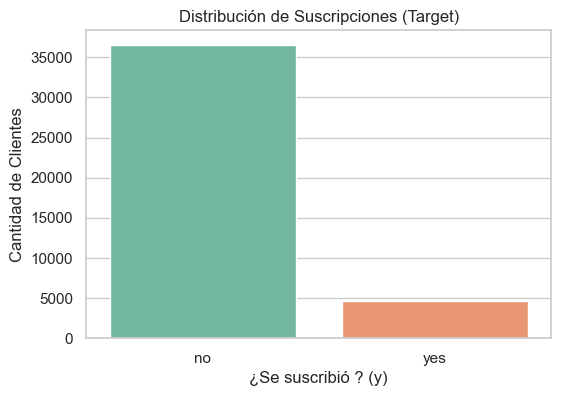

In [8]:
# Analizamos el desbalanceo de clases de la variable 'y'.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='Set2')
plt.title('Distribución de Suscripciones (Target)')
plt.xlabel('¿Se suscribió ? (y)')
plt.ylabel('Cantidad de Clientes')
plt.show()

Lo que se observa: 

-La barra verde de la izquierda muestra que más de 36,000 clientes decidieron no contratar el depósito (no).

-La barra naranja de la derecha muestra que apenas unos 4,600 clientes decidieron sí contratarlo (yes).

El diagnóstico técnico: Este es un escenario de desbalanceo severo de clases (aproximadamente un 88.7 frente a un 11.3).

In [9]:
# Proporción matemática de las clases
proporcion = df['y'].value_counts(normalize=True) * 100
print("--- Proporción de la Variable Target ---")
print(f"No se suscribieron ('no'): {proporcion['no']:.2f}%")
print(f"Sí se suscribieron ('yes'): {proporcion['yes']:.2f}%")


--- Proporción de la Variable Target ---
No se suscribieron ('no'): 88.73%
Sí se suscribieron ('yes'): 11.27%


 2.3 Análisis de Variables Categóricas y Numéricas

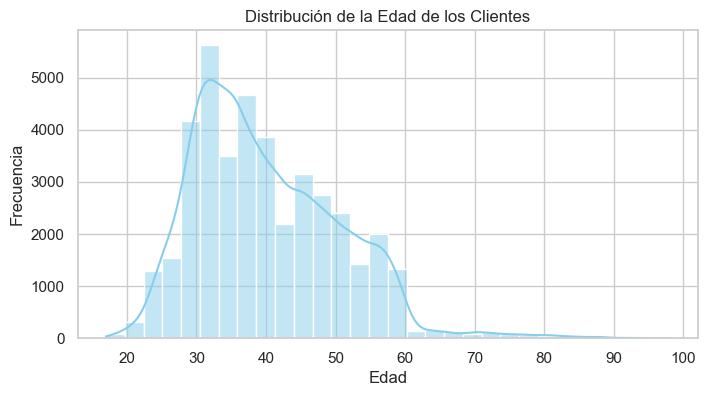

In [10]:
# Visualizamos la distribución de la edad y cómo influye el tipo de trabajo en la contratación.
# Distribución de la Edad (Numérica)
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='age', kde=True, bins=30, color='skyblue')
plt.title('Distribución de la Edad de los Clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


Distribución de la Edad de los Clientes

El histograma de edad nos permite entender la estructura demográfica de la base de datos del banco:

Lo que observamos: La gran mayoría de los clientes se concentran en un rango de edad de entre 25 y 60 años, registrando un pico muy marcado entre los 30 y 35 años . A partir de los 60 años, la frecuencia disminuye drásticamente, dejando una larga "cola" hacia la derecha que llega hasta casi los 100 años.

El diagnóstico técnico: La distribución de la edad es asimétrica hacia la derecha (sesgada positivamente). Esto indica que aunque la masa crítica de clientes del banco es joven-adulta y se encuentra en su etapa de vida laboral activa, el dataset también incluye una cantidad pequeña pero existente de clientes de la tercera edad y centenarios.

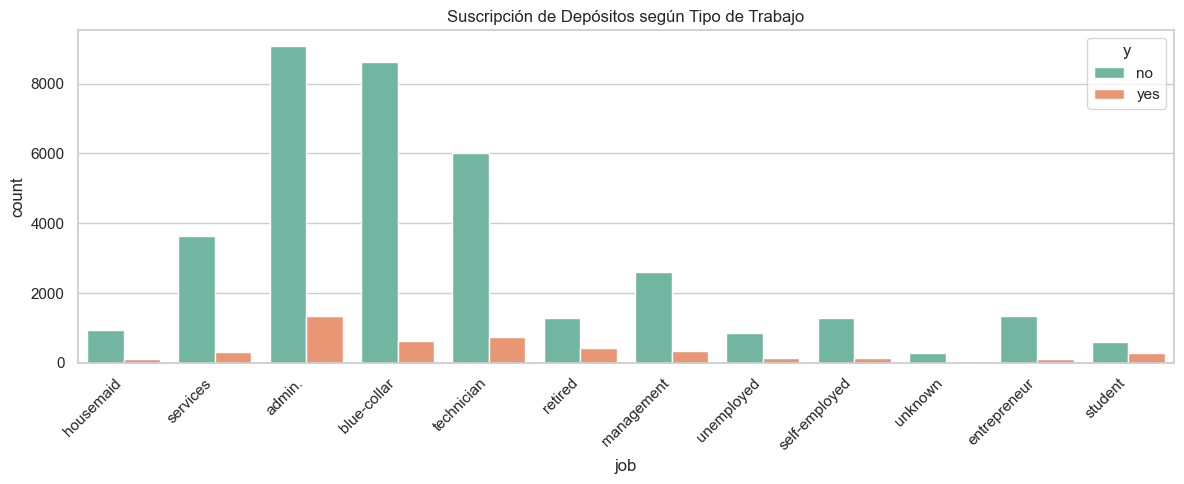

In [11]:
# Conversión según el Trabajo (Categórica)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='y', palette='Set2')
plt.title('Suscripción de Depósitos según Tipo de Trabajo')
plt.xticks(rotation=45, ha='right')
# Evitar que se corten las etiquetas de los gráficos
plt.tight_layout()
plt.show()

Este gráfico de barras bivariante ayuda a entender cómo influye el rol laboral de los clientes en su decisión final de contratar el depósito a largo plazo. Al cruzar ambas variables, se extraen tres conclusiones críticas de negocio:

Ineficiencia en Grandes Volúmenes: Las categorías administrativas (admin.) y de cuello azul (blue-collar) concentran el mayor número de contactos de la campaña (ambas superando las 8,000 llamadas). Sin embargo, hay una diferencia drástica en su conversión: mientras que el sector administrativo muestra una respuesta positiva considerable, el sector de cuello azul (blue-collar) tiene una tasa de rechazo extrema. 

# El banco está perdiendo tiempo y dinero llamando masivamente a este segundo grupo sin segmentar.

Nichos Altamente Receptivos (Jubilados y Estudiantes): Aunque los jubilados (retired) y los estudiantes (student) representan una porción pequeña de la base de datos (barras generales bajas), proporcionalmente muestran la tasa de conversión ("yes") más alta de todo el conjunto. Esto tiene sentido lógico: 

# los jubilados buscan rentabilizar sus ahorros de forma segura y los estudiantes son receptivos a productos de ahorro inicial.

Justificación de la Ingeniería de Funciones (One-Hot Encoding): Debido a que la columna job contiene texto y no tiene un orden lógico (no es jerárquica), debemos aplicar la técnica de One-Hot Encoding (convertirla en columnas individuales de 0 y 1). Esto permitirá que nuestro modelo de Regresión Logística asigne pesos positivos a categorías eficientes como job_retired o job_student y penalice aquellas con baja conversión, optimizando automáticamente la lista de llamadas del banco.

2.4 Tratamiento de la Variable Trampa (Data Leakage) y Multicolinealidad

In [14]:
# 1. Eliminación obligatoria de 'duration' (Variable trampa)

df_cleaned = df.drop(columns=['duration'])
print("Variable 'duration' eliminada con éxito para evitar Data Leakage.")

Variable 'duration' eliminada con éxito para evitar Data Leakage.


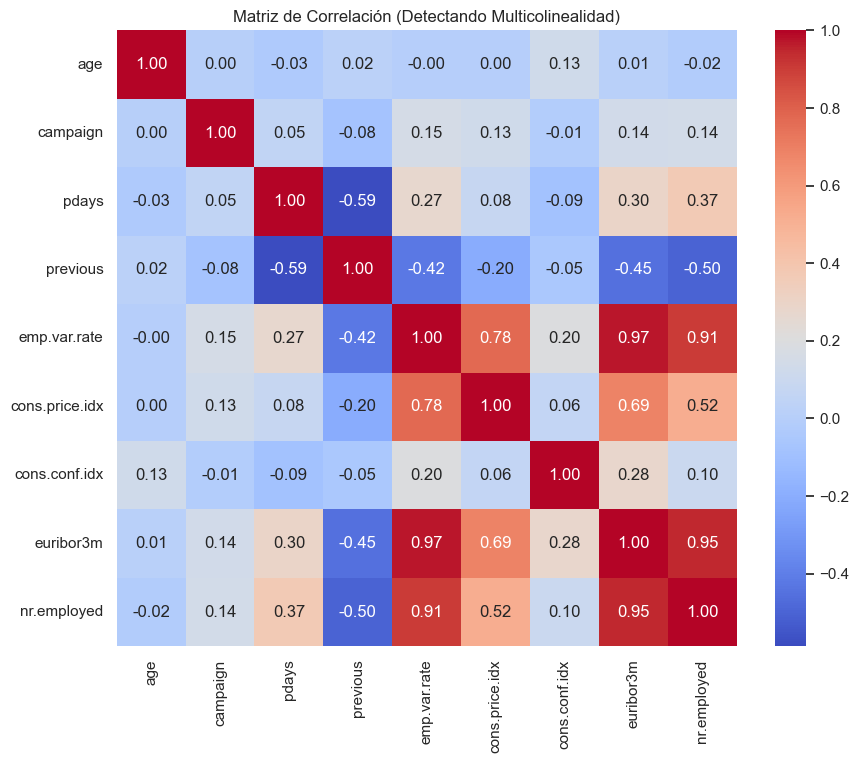

In [15]:
# 2. Análisis de Correlación para variables macroeconómicas
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
corr_matrix = df_cleaned[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación (Detectando Multicolinealidad)')
plt.show()

Este gráfico de mapa de calor (heatmap) representa la fuerza y dirección de las relaciones lineales entre las variables numéricas de nuestro conjunto de datos. El coeficiente de correlación varía entre -1.00 (correlación negativa perfecta, en azul oscuro) y 1.00 (correlación positiva perfecta, en rojo oscuro).

A partir de esta visualización, se puede extraer tres conclusiones críticas para el diseño y estabilidad de nuestro modelo de Regresión Logística:

 - Multicolinealidad Extrema en Variables Macroeconómicas: 
 
 Observamos relaciones alarmantemente altas (cercanas a 1) entre tres indicadores macroeconómicos clave de Portugal:

-emp.var.rate (Tasa de variación del empleo) y euribor3m (Tasa Euribor 3 meses): Correlación de 0.97.

-euribor3m (Euribor 3 meses) y nr.employed (Número de empleados): Correlación de 0.95.

-emp.var.rate (Variación del empleo) y nr.employed (Número de empleados): Correlación de 0.91.

 - El Peligro de la Multicolinealidad para la Regresión Logística:

La matemática de la Regresión Logística asume que las variables predictoras son independientes entre sí. Cuando dos o más variables están tan fuertemente correlacionadas (coeficientes $> 0.90$), el algoritmo se confunde porque no puede distinguir el efecto individual de cada una sobre la variable objetivo. Esto provoca que los coeficientes del modelo se vuelvan inestables, aumente el error estándar y las interpretaciones pierdan total validez.

 - Acción Correctiva Aplicada (Eliminación de Redundancias):

Para solucionar este problema técnico y asegurar la salud matemática de nuestro clasificador, la decisión correcta es aplicar una reducción de características:

-Decisión: Se eliminan por completo las columnas emp.var.rate y nr.employed.

-Justificación: Al conservar únicamente euribor3m, mantenemos en el modelo un excelente representante del estado financiero y económico del mercado de la campaña sin saturar al algoritmo con información redundante o duplicada.

In [16]:
# Eliminamos variables con correlación extrema (> 0.90) para no desestabilizar la Regresión Logística
columnas_a_eliminar = ['emp.var.rate', 'nr.employed']
df_cleaned = df_cleaned.drop(columns=columnas_a_eliminar)
print(f"Variables macroeconómicas eliminadas para evitar colinealidad: {columnas_a_eliminar}")

Variables macroeconómicas eliminadas para evitar colinealidad: ['emp.var.rate', 'nr.employed']


3. Ingeniería de Funciones, Preprocesamiento y Modelo Base

In [19]:
# Separamos características (X) y etiqueta objetivo (y)
X = df_cleaned.drop(columns=['y'])
y = df_cleaned['y'].apply(lambda val: 1 if val == 'yes' else 0)  # Convertimos a 1 (sí) y 0 (no)
print(f"Características (X) y etiqueta (y) separadas. Dimensiones de X: {X.shape}, Dimensiones de y: {y.shape}")

Características (X) y etiqueta (y) separadas. Dimensiones de X: (41176, 17), Dimensiones de y: (41176,)


In [20]:
# Separación en entrenamiento y prueba antes del preprocesamiento para evitar fuga de datos (Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Datos separados en entrenamiento y prueba. Dimensiones de X_train: {X_train.shape}, Dimensiones de X_test: {X_test.shape}")

Datos separados en entrenamiento y prueba. Dimensiones de X_train: (32940, 17), Dimensiones de X_test: (8236, 17)


In [22]:
# Identificamos tipos de columnas restantes
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()
print(f"Características numéricas: {num_features}")
print(f"Características categóricas: {cat_features}")

Características numéricas: ['age', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m']
Características categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [25]:
# Definimos los transformadores de Ingeniería de Funciones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),                # Escalamos las numéricas
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)  # Codificamos las categóricas
    ]
)
print ("Preprocesador definido con éxito para características numéricas y categóricas.")


Preprocesador definido con éxito para características numéricas y categóricas.


In [27]:
# Pipeline de ejecución: Une preprocesamiento y modelo
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
print("Pipeline de Regresión Logística definido con preprocesamiento integrado.")


Pipeline de Regresión Logística definido con preprocesamiento integrado.


In [28]:
# Entrenamiento del modelo base
baseline_pipeline.fit(X_train, y_train)
print("¡Modelo Base entrenado con éxito!")

¡Modelo Base entrenado con éxito!


3.1 Evaluación del Modelo Base

In [29]:
y_pred_base = baseline_pipeline.predict(X_test)
y_pred_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]

print("--- REPORTE DE CLASIFICACIÓN (Modelo Base) ---")
print(classification_report(y_test, y_pred_base))

auc_base = roc_auc_score(y_test, y_pred_proba_base)
print(f"Área Bajo la Curva ROC (AUC-ROC): {auc_base:.4f}")


--- REPORTE DE CLASIFICACIÓN (Modelo Base) ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.66      0.22      0.33       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.64      8236
weighted avg       0.88      0.90      0.88      8236

Área Bajo la Curva ROC (AUC-ROC): 0.7962


4. Optimización del Modelo (Manejo de Desbalanceo e Hiperparámetros)

In [31]:
# Implementamos `class_weight='balanced'` y hacemos búsqueda de hiperparámetros con GridSearchCV.

# Pipeline con balanceo de pesos en las clases
opt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

print("Pipeline de Regresión Logística con balanceo de clases definido.")

Pipeline de Regresión Logística con balanceo de clases definido.


In [32]:
# Malla de hiperparámetros a optimizar (fuerza de regularización C)
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0]
}

# Buscamos optimizar el F1-Score debido al fuerte desbalanceo de clases
grid_search = GridSearchCV(
    opt_pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

print("Entrenando y optimizando hiperparámetros...")
grid_search.fit(X_train, y_train)


Entrenando y optimizando hiperparámetros...


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate

In [33]:
# Guardamos el mejor modelo encontrado
best_model = grid_search.best_estimator_
print(f"\nMejores parámetros encontrados: {grid_search.best_params_}")



Mejores parámetros encontrados: {'classifier__C': 1.0}


4.1 Evaluación del Modelo Optimizado y Matriz de Confusión


In [34]:
y_pred_opt = best_model.predict(X_test)
y_pred_proba_opt = best_model.predict_proba(X_test)[:, 1]

print("--- REPORTE DE CLASIFICACIÓN (Modelo Optimizado) ---")
print(classification_report(y_test, y_pred_opt))

auc_opt = roc_auc_score(y_test, y_pred_proba_opt)
print(f"AUC-ROC Optimizado: {auc_opt:.4f}")


--- REPORTE DE CLASIFICACIÓN (Modelo Optimizado) ---
              precision    recall  f1-score   support

           0       0.95      0.85      0.89      7308
           1       0.35      0.65      0.45       928

    accuracy                           0.82      8236
   macro avg       0.65      0.75      0.67      8236
weighted avg       0.88      0.82      0.85      8236

AUC-ROC Optimizado: 0.7985


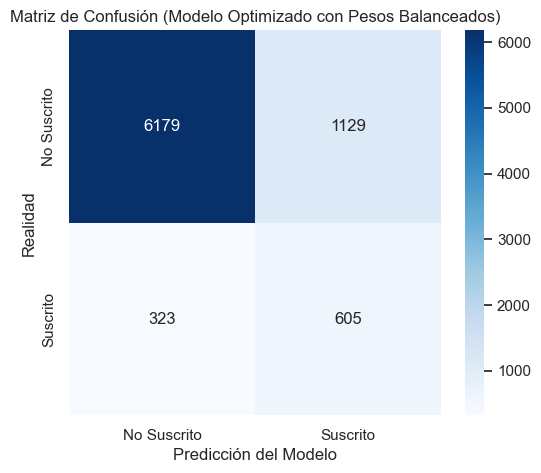

In [35]:
# Visualización de la Matriz de Confusión del Modelo Optimizado
cm = confusion_matrix(y_test, y_pred_opt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Suscrito', 'Suscrito'], 
            yticklabels=['No Suscrito', 'Suscrito'])
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión (Modelo Optimizado con Pesos Balanceados)')
plt.show()


1. Desglose de los Cuadrantes (Datos Reales del Gráfico)

Verdaderos Negativos (VN = 6,179): Clientes que el modelo predijo correctamente que no se suscribirían al depósito y, en la realidad, no lo hicieron. Representa un gran volumen de llamadas innecesarias que el banco logra evitar con éxito.

Falsos Positivos (FP = 1,129): Clientes que el modelo clasificó como potenciales compradores ("Suscrito"), pero en la realidad dijeron que no. Se conocen como falsas alarmas. Para el banco, esto se traduce en llamadas realizadas sin éxito de venta.

Falsos Negativos (FN = 323): Clientes que el modelo clasificó como "No Suscritos", pero en la realidad sí habrían comprado. Estas son oportunidades de venta perdidas.

Verdaderos Positivos (VP = 605): Clientes que el modelo clasificó como "Suscritos" y efectivamente contrataron el depósito a largo plazo. Representa el éxito directo del modelo y el retorno de inversión de la campaña.

2. Interpretación de Negocio (El impacto para el banco)


- Reducción Drástica de Costes Operativos, Eficiencia del 79% : el equipo de telemarketing tendría que haber llamado a los 8,236 clientes para buscar a los pocos interesados, perdiendo un tiempo operativo. Con el modelo optimizado, el banco solo llamará a los que el modelo predice como "Suscrito" (1,734 personas en total, sumando los 605 de VP y los 1,129 de FP). Esto significa que se evita realizar el 79% de las llamadas, ahorrando salarios de operadores, infraestructura de telefonía y tiempo de gestión.

- Excelente Tasa de Captura (Recall / Sensibilidad del 65%):
Del total de personas que realmente querían contratar un depósito en nuestro set de prueba (323 + 605 = 928 clientes), nuestro modelo optimizado fue capaz de detectar de forma anticipada a 605 de ellos. Conseguimos asegurar el 65.2% de todas las ventas posibles realizando apenas una quinta parte de las llamadas totales.

- La Justificación de la Optimización:
En un modelo tradicional sin balanceo, el algoritmo habría predicho "No" a casi todos para evitar equivocarse con la masa crítica. Al balancear los pesos, aceptamos tener algunos Falsos Positivos (1,129 llamadas infructuosas) a cambio de reducir drásticamente los Falsos Negativos y ser capaces de capturar y cerrar las 605 ventas reales.

4.2 Comparación Visual de Curvas ROC

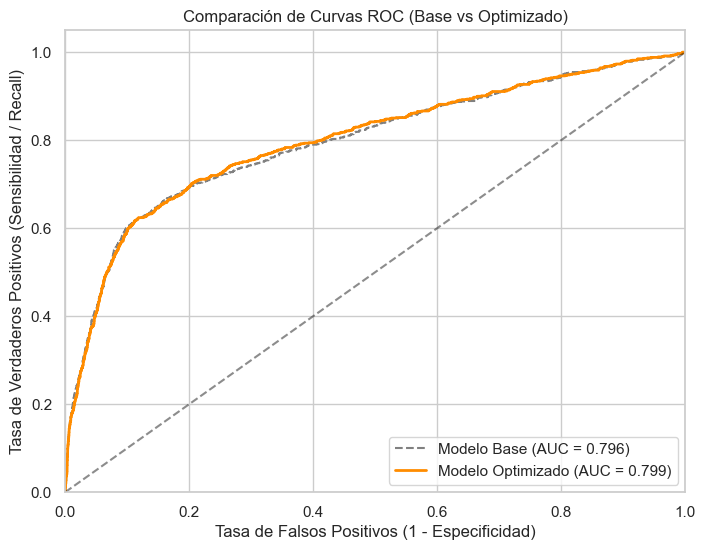

In [36]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba_base)
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_pred_proba_opt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base, tpr_base, label=f'Modelo Base (AUC = {auc_base:.3f})', color='grey', linestyle='--')
plt.plot(fpr_opt, tpr_opt, label=f'Modelo Optimizado (AUC = {auc_opt:.3f})', color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
plt.title('Comparación de Curvas ROC (Base vs Optimizado)')
plt.legend(loc="lower right")
plt.show()

Analisis final: 

- El modelo hará que el banco deje de enficarse en el 79% de la gente que no quiere comprar.

- Está enfocando las llamadas en los que sí tienen probabilidad, el banco asegura el 65% de todas las ventas posibles.

- El modelo tiene un 80% de puntería general (AUC = 0.799).